# 1. Streszczenie

Projekt dotyczy klasyfikacji języka mówionego na podstawie nagrań audio. Wykorzystano bibliotekę Librosa do ekstrakcji 128 współczynników cepstralnych w skali melowej (MFCC), które uśredniono w czasie do postaci wektorów cech. Opracowano model Głębokiej Sieci Neuronowej w środowisku TensorFlow/Keras. Ze względu na ryzyko przeuczenia zastosowano techniki regularyzacji oraz wczesne zatrzymywanie. Model z powodzeniem uczy się charakterystyki częstotliwościowej poszczególnych języków, osiągając stabilną i zadowalającą dokładność klasyfikacji na zbiorze testowym.

# 2. Wstęp / wprowadzenie

Rozpoznawanie języka mówionego to jedno z fundamentalnych zagadnień w dziedzinie cyfrowego przetwarzania sygnału i uczenia maszynowego. Automatyczna identyfikacja języka pozwala na efektywne kierowanie strumieni audio do odpowiednich modeli transkrypcji i tłumaczenia. Głównym wyzwaniem w tego typu projektach jest odpowiednia reprezentacja niestacjonarnego sygnału dźwiękowego, aby mógł on zostać podany na wejście klasyfikatora. W niniejszym projekcie zrezygnowano z podawania surowej fali dźwiękowej na rzecz analizy widmowej. Wykorzystano głębokie sieci neuronowe, bazując na architekturze w pełni połączonej (Dense), analizującej zagregowane cechy akustyczne z nagrań mowy.

# 3. Opis kontekstu i celu projektu

Kontekstem projektu jest stworzenie narzędzia automatyzującego wstępną analizę nagrań wielojęzycznych. Głównym celem było zaprojektowanie, zoptymalizowanie i wytrenowanie modelu klasyfikacyjnego potrafiącego odróżnić języki na podstawie krótkich próbek dźwiękowych.

Cele szczegółowe obejmowały:
*   Masową i zoptymalizowaną czasowo ekstrakcję cech z tysięcy plików audio.
*   Zbudowanie modelu z zachowaniem zasad zapobiegania przeuczeniu, który potrafi generalizować wiedzę.
*   Dobór odpowiednich hiperparametrów i obiektywną ewaluację architektury.


# 4. Literatura

1. MFCC – ekstrakcja cech
Davis & Mermelstein (1980) – Comparison of Parametric Representations for Monosyllabic Word Recognition

IEEE Transactions on Acoustics, Speech, and Signal Processing, 28(4):357–366
Klasyczna, fundamentalna praca definiująca MFCC. Cytowana w niemal każdej pracy ze speech processing – punkt wyjścia dla zrozumienia tej techniki ekstrakcji cech.

2. Bartz et al. (2017) – Language Identification Using Deep Convolutional Recurrent Neural Networks

ICONIP 2017, SpringerModel CRNN łączący CNN i RNN – podejście to osiągnęło 92% dokładności i 97% pairwise accuracy w rozpoznawaniu języka na krótkich klipach z datasetu Mozilla Common Voice dla 5 języków (DE, EN, ES, FR, RU).
https://towardsdatascience.com/spoken-language-recognition-on-mozilla-common-voice-part-ii-models-b32780ea1ee4/

3. CNN + mel-spektrogramy vs. MFCC Singh et al. (2021) – Spoken Language Identification Using Deep Learning

DOI: 10.1155/2021/5123671
CNN trenowana na spektrogramach audio osiągnęła ~98% dokładności dla 25 języków. Pliki audio konwertowane były do obrazów spektrogramów, z których CNN wyodrębniała cechy klasyfikacyjne.
https://pmc.ncbi.nlm.nih.gov/articles/PMC8478554/

In [1]:
!pip install resampy

import IPython.display as ipd
import librosa
import librosa.display
import pandas as pd
import os, time, warnings
import seaborn as sns
import numpy as np
import resampy
import numba
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Flatten,
    Conv2D,
    MaxPool2D,
    Activation
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold, ParameterGrid

warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Zbiór danych jezykowych: https://mozilladatacollective.com/organization/cmfh0j9o10006ns07jq45h7xk

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(42)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATA_PATH = "/content/drive/MyDrive/voices"
VOICES = os.listdir(DATA_PATH)
print(f"Total voices: {len(VOICES)}: {', '.join(VOICES)}")

Total voices: 4: hebrew, korean, polish, czech


# 5. Opis danych
Pierwotny korpus danych zebranych na potrzeby projektu był niezwykle obszerny i składał się z około 400 000 nagrań audio. Ze względu na drastyczne ograniczenia zasobów sprzętowych, a także limity przestrzeni dyskowej w chmurze obliczeniowej, przetwarzanie całości było technicznie niewykonalne. W związku z tym podjęto świadomą decyzję inżynierską o rygorystycznym podpróbkowaniu zbioru. Zbiór został zredukowany przy losowym usuwaniu plików z zachowaniem równowagi klas, ograniczając się do max 10000 próbek na każdą kategorię językową. Ten zoptymalizowany podzbiór stanowił bazę do dalszej ekstrakcji cech.



In [5]:
def get_ds_paths(input_dir):
    data = []

    for dirs in VOICES:
        clips_path = os.path.join(input_dir, dirs, "clips")

        if os.path.exists(clips_path):
            for file_name in os.listdir(clips_path):
                full_path = os.path.join(clips_path, file_name).replace("\\", "/")

                data.append({
                    "path": full_path,
                    "language": dirs
                })
        else:
            print(f"Ostrzeżenie: Folder {clips_path} nie istnieje!")

    return pd.DataFrame(data)


df = get_ds_paths(DATA_PATH)
df.head()

,path,language
0,/content/drive/MyDrive/voices/hebrew/clips/com...,hebrew
1,/content/drive/MyDrive/voices/hebrew/clips/com...,hebrew
2,/content/drive/MyDrive/voices/hebrew/clips/com...,hebrew
3,/content/drive/MyDrive/voices/hebrew/clips/com...,hebrew
4,/content/drive/MyDrive/voices/hebrew/clips/com...,hebrew


Sprawdzamy rozłożenie klas w naszym zbiorze danych

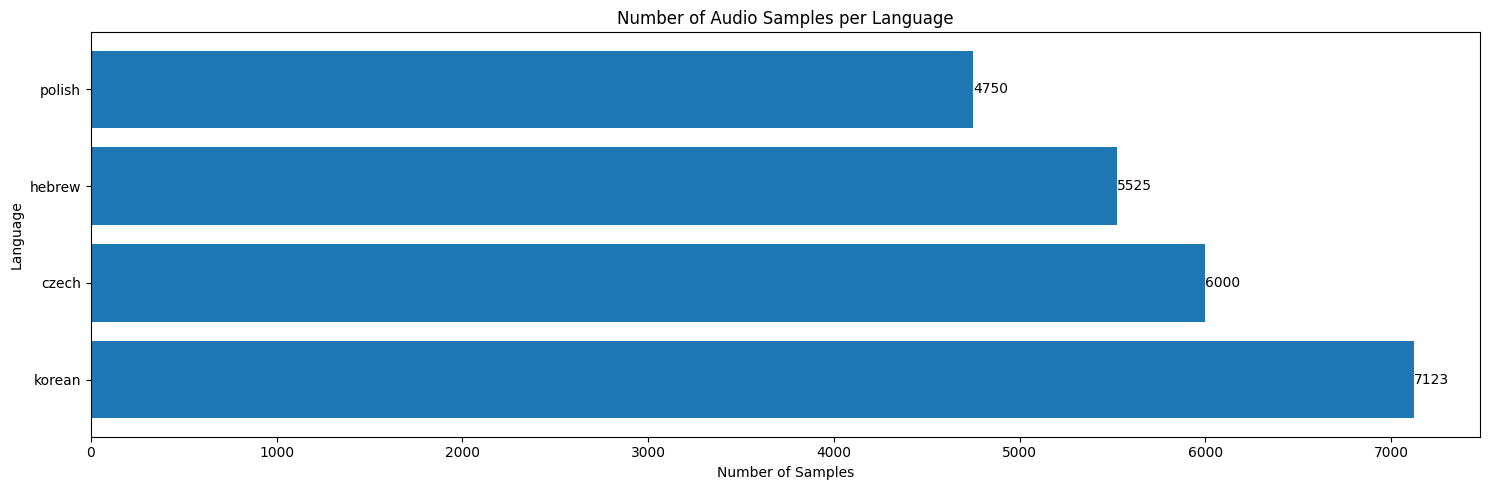

In [6]:
counts = df["language"].value_counts()

y = counts.values
labels = counts.index
ind = np.arange(len(y))

fig, ax = plt.subplots(figsize=(15, 5))
ax.barh(ind, y)
ax.set_yticks(ind)

ax.set_yticklabels(labels)
ax.bar_label(ax.containers[0])

plt.gcf().set_dpi(100)

plt.title("Number of Audio Samples per Language")
plt.xlabel("Number of Samples")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

Sygnał audio poddano transformacji wykorzystując bibliotekę Librosa. Nagrania wczytywano za pomocą zoptymalizowanego algorytmu res_type="kaiser_fast", co drastycznie skróciło czas ładowania. Z każdego nagrania wyekstrahowano wektor 128 cech MFCC, które następnie uśredniono w dziedzinie czasu (np.mean(feature.T, axis=0)). Dzięki temu uzyskano stałą wielkość wektora wejściowego niezależnie od długości trwania nagrania. Etykiety klas (języki) zostały zakodowane za pomocą metody One-Hot Encoding. Całość została połączona i zapisana w strukturze pandas DataFrame, z której wydzielono podzbiór treningowy, walidacyjny oraz testowy.

In [8]:
import librosa
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor

def process_single_file(row):
    file_name = row["path"]
    final_class_labels = row["language"]

    try:
        audio, sample_rate = librosa.load(file_name, res_type="kaiser_fast")
        feature = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
        scaled_feature = np.mean(feature.T, axis=0)
        return [file_name, scaled_feature, final_class_labels]
    except Exception as e:
        return None

def split_data(df, max_sample_category=5000):
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df_filtered = df_shuffled.groupby("language").head(max_sample_category)

    print(f"Rozpoczynam przetwarzanie {len(df_filtered)} plików na wszystkich rdzeniach CPU...")

    rows = [row for _, row in df_filtered.iterrows()]

    with ProcessPoolExecutor() as executor:
        results = list(tqdm(executor.map(process_single_file, rows), total=len(rows)))

    extracted = [x for x in results if x is not None]

    extracted_df = pd.DataFrame(extracted, columns=["path", "feature", "class"])
    return extracted_df

extracted_df = split_data(df)

Rozpoczynam przetwarzanie 19750 plików na wszystkich rdzeniach CPU...


  0%|          | 0/19750 [00:00<?, ?it/s]

Przetwarzany zbiór danych

In [9]:
extracted_df.head()

,path,feature,class
0,/content/drive/MyDrive/voices/polish/clips/com...,"[-361.98236, 67.556885, -3.838012, 33.090534, ...",polish
1,/content/drive/MyDrive/voices/czech/clips/comm...,"[-413.23553, 102.615036, -3.1782055, 11.468473...",czech
2,/content/drive/MyDrive/voices/hebrew/clips/com...,"[-452.8951, 76.57827, 38.137074, 28.459873, -3...",hebrew
3,/content/drive/MyDrive/voices/hebrew/clips/com...,"[-295.92746, 109.65142, -30.059538, 21.038157,...",hebrew
4,/content/drive/MyDrive/voices/polish/clips/com...,"[-194.67383, 62.378387, 24.462967, 13.014643, ...",polish


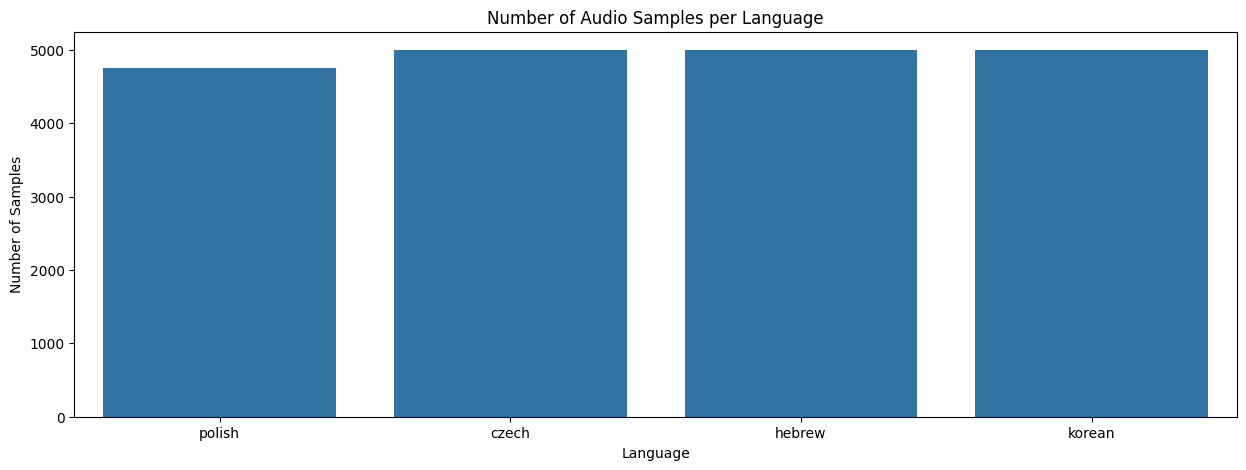

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.countplot(data=extracted_df, x="class", ax=ax)

plt.title("Number of Audio Samples per Language")
plt.ylabel("Number of Samples")
plt.xlabel("Language")
plt.show()

In [11]:
X = np.array(extracted_df["feature"].tolist())
y = np.array(extracted_df["class"].tolist())

# label encoding to get encoding
le = LabelEncoder()
# transform each category with it's respected label
Y = to_categorical(le.fit_transform(y))

In [12]:
# split the data to train and test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# print the details
print("Number of training samples = ", X_train.shape[0])
print("Number of testing samples = ", X_test.shape[0])

Number of training samples =  15800
Number of testing samples =  3950


# ANN_Model

## 1. Architektura modelu

Model zbudowany jest jako wielowarstwowa sieć neuronowa typu feedforward (MLP – Multilayer Perceptron) z wykorzystaniem interfejsu `Sequential` biblioteki Keras/TensorFlow.


### Schemat warstw

| Warstwa | Neurony | Funkcja aktywacji | Regularyzacja |
|---|---|---|---|
| Dense 1 | 512 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 2 | 256 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 3 | 128 | ReLU | BatchNorm + Dropout(0.3) |
| Dense (wyjście) | `num_labels` | Softmax | – |


### Opis poszczególnych elementów

**Warstwy gęste (Dense)**  
Każda warstwa gęsta jest w pełni połączona z poprzednią – każdy neuron otrzymuje sygnały ze wszystkich neuronów warstwy poprzedniej. Sieć stopniowo redukuje wymiarowość reprezentacji: 512 → 256 → 128 → `num_labels`, co wymusza hierarchiczne wyodrębnianie coraz bardziej abstrakcyjnych cech językowych z wektora MFCC.

**Batch Normalization**  
Normalizuje aktywacje każdej warstwy w obrębie mini-batcha, stabilizując proces uczenia i pozwalając na stosowanie wyższych współczynników uczenia. Umieszczona przed funkcją aktywacji, zgodnie z oryginalną propozycją Ioffe & Szegedy (2015).

**Funkcja aktywacji ReLU**  
Rectified Linear Unit (ReLU) — `f(x) = max(0, x)` — stosowana w ukrytych warstwach jako nieliniowość. Przyspiesza zbieżność i ogranicza problem zanikającego gradientu w porównaniu z funkcjami sigmoidalną lub tanh.

**Dropout (p = 0.3)**  
Podczas trenowania losowo zeruje 30% neuronów w każdej iteracji, co redukuje przeuczenie. Stosowany po każdej warstwie ukrytej, wyłączany automatycznie w fazie ewaluacji.

**Warstwa wyjściowa – Softmax**  
Przekształca surowe logity na rozkład prawdopodobieństwa nad `num_labels` klasami (językami). Klasa z najwyższym prawdopodobieństwem jest predykcją modelu.

---

## 2. Kompilacja modelu

```python
optimizer = Adam(learning_rate=0.0005)

ANN_Model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
```

**Optymalizator Adam** (Kingma & Ba, 2014) łączy zalety metod AdaGrad i RMSProp, adaptując współczynnik uczenia indywidualnie dla każdego parametru. Wartość wspóczynnika uczenia została ustawiona jako `learning_rate=0.0005`.

**Funkcja straty `categorical_crossentropy`** stosowana jest do problemów klasyfikacji wieloklasowej z kodowaniem one-hot etykiet, minimalizując ujemne log-prawdopodobieństwo poprawnej klasy.

---

## 3. Trenowanie modelu

```python
num_epochs     = 150
num_batch_size = 128
```

Model trenowany był przez maksymalnie **150 epok** z rozmiarem mini-batcha wynoszącym **128 próbek**.

### Mechanizmy regularizacji procesu uczenia

#### Early Stopping
```python
EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
```
Przerywa trening, jeśli wartość `val_loss` nie poprawia się przez **10 kolejnych epok**. Parametr `restore_best_weights=True` przywraca wagi z epoki o najniższej stracie walidacyjnej, eliminując ręczny dobór momentu zatrzymania.

#### Model Checkpoint
```python
ModelCheckpoint(filepath="Model1_best.keras", monitor='val_accuracy',
                save_best_only=True, mode='max')
```
Zapisuje model na dysk wyłącznie wtedy, gdy `val_accuracy` osiąga nowe maksimum. Gwarantuje zachowanie najlepszej wersji modelu niezależnie od dalszego przebiegu treningu.

#### Reduce LR on Plateau
```python
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
```
Zmniejsza współczynnik uczenia o połowę (`factor=0.5`), gdy `val_loss` nie spada przez **3 epoki**. Pozwala modelowi na dokładniejsze dostrajanie wag w okolicach minimum funkcji straty. Minimalny dozwolony współczynnik uczenia wynosi `1e-5`.

### Dane treningowe i walidacyjne

```python
ANN_Results = ANN_Model.fit(
    X_train, y_train,
    batch_size=num_batch_size,
    epochs=num_epochs,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)
```

Model uczony jest na zbiorze `X_train` / `y_train`. Po każdej epoce oceniany na zbiorze `X_test` / `y_test`. Dane wejściowe `X` stanowią wektory cech MFCC wyekstrahowanych z nagrań audio (Mozilla Common Voice), a `y` to zakodowane one-hot etykiety klas językowych.

---

## 4. Podsumowanie

Zastosowana przez nas architektura ANN stanowi klasyczny model MLP z hierarchiczną redukcją wymiarowości i trzema niezależnymi mechanizmami zapobiegającymi przeuczeniu: Batch Normalization, Dropout oraz Early Stopping. Adaptacyjny optymalizator Adam wraz z callbackiem `ReduceLROnPlateau` zapewniają stabilne uczenie na wektorach cech MFCC.

In [13]:
num_labels = Y.shape[1]

ANN_Model = Sequential()

ANN_Model.add(Dense(512))
ANN_Model.add(BatchNormalization())
ANN_Model.add(Activation('relu'))
ANN_Model.add(Dropout(0.3))

ANN_Model.add(Dense(256))
ANN_Model.add(BatchNormalization())
ANN_Model.add(Activation('relu'))
ANN_Model.add(Dropout(0.3))

ANN_Model.add(Dense(128))
ANN_Model.add(BatchNormalization())
ANN_Model.add(Activation('relu'))
ANN_Model.add(Dropout(0.3))


ANN_Model.add(Dense(num_labels, activation="softmax"))

optimizer = Adam(learning_rate=0.0005)

ANN_Model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ANN_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Poniższy kod:
1. trenuje model neuronowy,
2. zapisuje wytrenowany model,
3. zapisuje historię treningu,

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

num_epochs = 150
num_batch_size = 128

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="Model1_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

t0 = time.time()

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

ANN_Results = ANN_Model.fit(
    X_train,
    y_train,
    batch_size=num_batch_size,
    epochs=num_epochs,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

ANN_Model.save("Model1.keras")
print("ANN Model Saved (Format .keras)")

train_hist_m1 = pd.DataFrame(ANN_Results.history)
train_m1 = round(time.time() - t0, 3)
print(f"Czas trenowania: {train_m1} sekund")

Epoch 1/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5442 - loss: 1.0818 - val_accuracy: 0.3972 - val_loss: 1.3167 - learning_rate: 5.0000e-04
Epoch 2/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6639 - loss: 0.8327 - val_accuracy: 0.7195 - val_loss: 0.7180 - learning_rate: 5.0000e-04
Epoch 3/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7144 - loss: 0.7248 - val_accuracy: 0.7256 - val_loss: 0.6734 - learning_rate: 5.0000e-04
Epoch 4/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7416 - loss: 0.6562 - val_accuracy: 0.7509 - val_loss: 0.6466 - learning_rate: 5.0000e-04
Epoch 5/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7651 - loss: 0.5993 - val_accuracy: 0.7570 - val_loss: 0.5962 - learning_rate: 5.0000e-04
Epoch 6/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7867 - loss: 0.5501 - val_accuracy: 0.8003 - val_loss: 0.5163 - learning_rate: 5.0000e-04
Epoch 7/150
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/ste

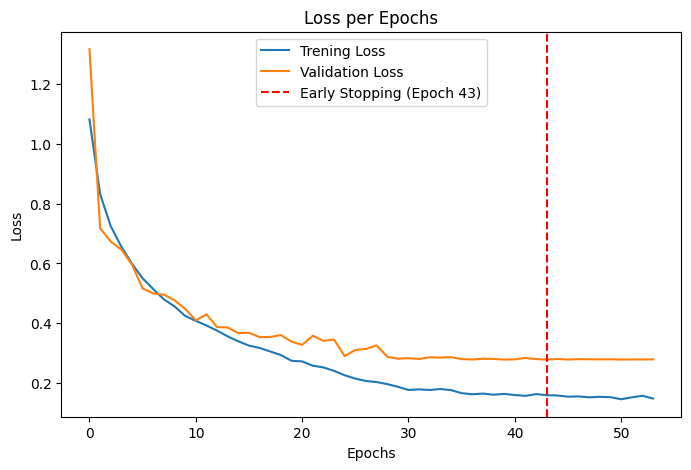

In [15]:
import numpy as np
import matplotlib.pyplot as plt

best_epoch = np.argmin(train_hist_m1["val_loss"])

plt.figure(figsize=(8, 5))
plt.plot(train_hist_m1[["loss", "val_loss"]])

plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Zapisany model (Epoka {best_epoch})')

plt.legend(["Trening Loss", "Validation Loss", f"Early Stopping (Epoch {best_epoch})"])
plt.title("Loss per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

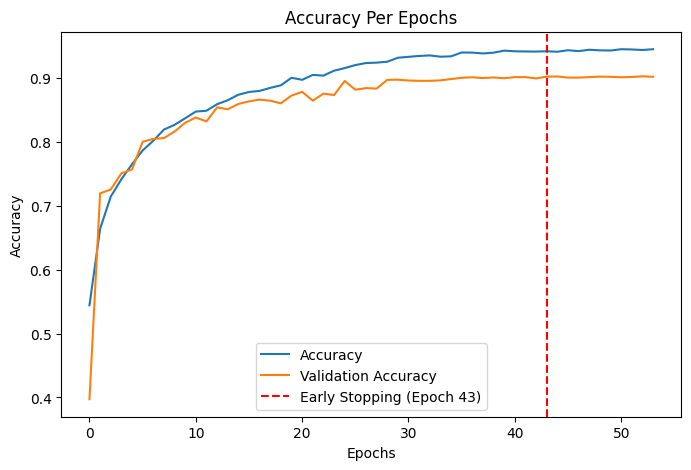

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m1[["accuracy", "val_accuracy"]])
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Zapisany model (Epoka {best_epoch})')
plt.legend(["Accuracy", "Validation Accuracy", f"Early Stopping (Epoch {best_epoch})"])
plt.title("Accuracy Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Ten kod tworzy system do porównywania modeli ML/AI — zapisuje accuracy, czas treningu i czas predykcji do jednej tabeli

In [25]:
log_cols = ["model", "accuracy", "train_time", "pred_time"]
log = pd.DataFrame(columns=log_cols)

def Log_Model(model, model_name, x, y, t):
    global log
    acc = model.evaluate(x, y, verbose=0)
    t0 = time.time()
    y_pred = model.predict(x, verbose=0)
    pred = round(time.time() - t0, 3)
    log_entry = pd.DataFrame([[model_name, acc[1] * 100, t, pred]], columns=log_cols)
    log = pd.concat([log, log_entry], ignore_index=True)

In [26]:
Log_Model(ANN_Model, "ANN", X_test, y_test, train_m1)
log

,model,accuracy,train_time,pred_time
0,ANN,90.227848,120.56,0.368


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


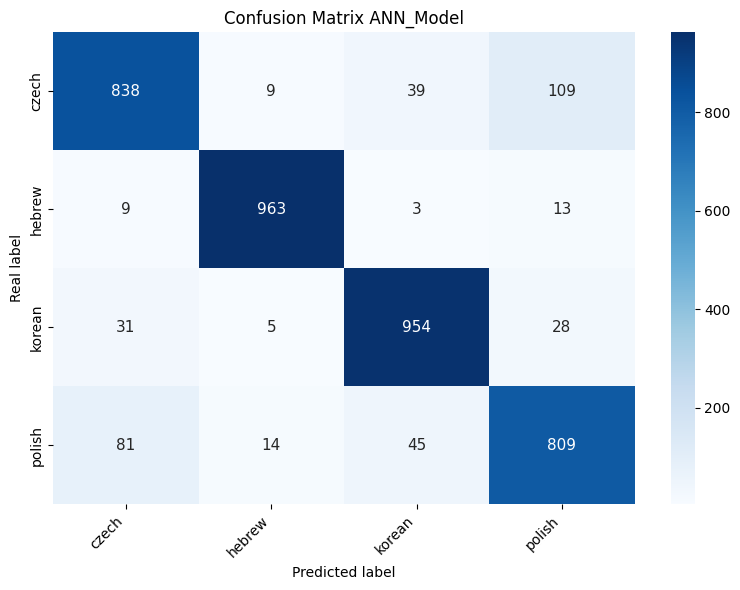

In [27]:
from sklearn.metrics import confusion_matrix

model, test_x, test_y = ANN_Model, X_test, y_test

y_pred = model.predict(test_x)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_y, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

class_names = le.classes_

plt.figure(figsize=(8, 6), dpi=100)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11})

plt.title('Confusion Matrix ANN_Model')
plt.ylabel('Real label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [28]:
def ANN_Prediction(file_name):
    # load the audio file
    audio_data, sample_rate = librosa.load(file_name, res_type="soxr_hq")
    # get the feature
    feature = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=128)
    # scale the features
    feature_scaled = np.mean(feature.T, axis=0)
    # array of features
    prediction_feature = np.array([feature_scaled])
    # get the id of label using argmax
    predicted_vector = np.argmax(ANN_Model.predict(prediction_feature), axis=-1)
    # get the class label from class id
    predicted_class = le.inverse_transform(predicted_vector)
    # display the result
    print("ANN has predicted the class as  --> ", predicted_class[0])

# File name
random_index = np.random.randint(0, len(extracted_df))
file_name = extracted_df.loc[random_index, 'path']
print(f"Randomly selected file for ANN_Prediction: {file_name}")
# get the output
ANN_Prediction(file_name)
# play the file
ipd.Audio(file_name)

Randomly selected file for ANN_Prediction: /content/drive/MyDrive/voices/korean/clips/common_voice_ko_37159842.mp3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
ANN has predicted the class as  -->  korean


In [29]:
xTrainval, xTest, yTrainval, yTest = train_test_split(
    X, Y, test_size=0.1, stratify=y, random_state=387
)
xTrain, xvalid, yTrain, yvalid = train_test_split(
    xTrainval, yTrainval, test_size=0.2, stratify=yTrainval, random_state=387
)
print("\nNumber of samples for Train set :", xTrain.shape[0])
print("Number of samples for Validation set :", xvalid.shape[0])
print("Number of samples for Test set :", xTest.shape[0])

xTrain = np.expand_dims(xTrain, axis=2)
xvalid = np.expand_dims(xvalid, axis=2)

print("Shape of X Train", xTrain.shape)
print("Shape of X Test", xTest.shape)


Number of samples for Train set : 14220
Number of samples for Validation set : 3555
Number of samples for Test set : 1975
Shape of X Train (14220, 128, 1)
Shape of X Test (1975, 128)


# CNN1D_Model

## 1. Architektura modelu

Model zbudowany jest jako 1D Convolutional Neural Network z wykorzystaniem interfejsu `Sequential` biblioteki Keras/TensorFlow. Architektura CNN1D przetwarza sekwencję cech MFCC bezpośrednio jako sygnał jednowymiarowy.

### Schemat warstw

| Blok | Warstwa | Filtry / Neurony | Kernel / Pool | Regularyzacja |
|---|---|---|---|---|
| Blok 1 | Conv1D | 256 | kernel=5, stride=1, padding=same | BatchNorm + ReLU + MaxPool(3, stride=2) + Dropout(0.2) |
| Blok 2 | Conv1D | 128 | kernel=5, stride=1, padding=same | BatchNorm + ReLU + MaxPool(3, stride=2) + Dropout(0.2) |
| Blok 3 | Conv1D | 64  | kernel=5, stride=1, padding=same | BatchNorm + ReLU + MaxPool(3, stride=2) + Dropout(0.2) |
| Klasyfikator | Flatten → Dense | 256 | – | BatchNorm + ReLU + Dropout(0.3) |
| Wyjście | Dense | `num_labels` | – | Softmax |

### Opis poszczególnych elementów

**Warstwy splotowe Conv1D**  
Każda warstwa stosuje filtry o rozmiarze jądra `kernel_size=5` przesuwane wzdłuż osi czasowej sekwencji MFCC z krokiem `strides=1`. Padding `"same"` zapewnia, że długość wyjścia jest równa długości wejścia przed poolingiem, umożliwiając równomierne próbkowanie cech na wszystkich poziomach. Sieć stopniowo redukuje liczbę filtrów: 256 → 128 → 128 → 64, co odzwierciedla przejście od cech niskopoziomowych (lokalne kształty widmowe) do bardziej abstrakcyjnych reprezentacji języka.

**Batch Normalization**  
Normalizuje aktywacje wewnątrz każdego mini-batcha po warstwie splotowej, przed funkcją aktywacji. Stabilizuje gradienty i przyspiesza zbieżność, szczególnie istotne przy głębszych architekturach splotowych.

**Funkcja aktywacji ReLU**  
Rectified Linear Unit wprowadza nieliniowość po każdej warstwie splotowej, pozwalając sieci na modelowanie złożonych zależności w danych akustycznych.

**MaxPooling1D (pool_size=3, strides=2)**  
Po każdym bloku splotowym następuje podpróbkowanie maksymalne o rozmiarze okna `3` i kroku `2`. Redukuje wymiar czasowy sekwencji o około połowę w każdym bloku, zmniejszając liczbę parametrów i wymuszając niezmienniczość translacyjną – model uczy się wzorców niezależnie od ich dokładnej pozycji w czasie.

**Dropout (p = 0.2 / 0.3)**  
Losowe zerowanie neuronów: 20% po każdym bloku splotowym oraz 30% po warstwie gęstej. Zapobiega co-adaptacji filtrów i redukuje przeuczenie.

**Flatten**  
Spłaszcza trójwymiarowy tensor `(batch, timesteps, filters)` do wektora cech, stanowiąc pomost między częścią splotową a klasyfikatorem.

**Warstwa gęsta (Dense 256)**  
Warstwa w pełni połączona, która integruje lokalne cechy temporalne wyodrębnione przez bloki splotowe w globalną reprezentację całej wypowiedzi.

**Warstwa wyjściowa – Softmax**  
Przekształca logity na rozkład prawdopodobieństwa po wszystkich `num_labels` klasach językowych. Klasa z najwyższym prawdopodobieństwem stanowi predykcję modelu.

---

## 2. Kompilacja modelu

```python
optimizer = Adam(learning_rate=0.0005)

CNN1D_Model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
```

**Optymalizator Adam** (Kingma & Ba, 2014) z `learning_rate=0.0005` adaptuje indywidualny współczynnik uczenia dla każdego parametru modelu, łącząc zalety metod momentum i RMSProp.

**Funkcja straty `categorical_crossentropy`** minimalizuje ujemne log-prawdopodobieństwo poprawnej klasy, właściwa dla wieloklasowej klasyfikacji z kodowaniem one-hot etykiet.

---

## 3. Trenowanie modelu

Model trenowany jest na cechach MFCC przekształconych do postaci sekwencji 3D `(samples, timesteps, 1)`, co odpowiada oczekiwanemu wejściu warstwy `Conv1D`.

### Callbacki

#### Early Stopping
```python
EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
```
Przerywa trening, jeśli `val_loss` nie spada przez **6 kolejnych epok**. Krótszy `patience` niż w modelu ANN (10 epok) wymusza szybszą reakcję na plateau, ze względu na głębokość i podatność CNN na przeuczenie po wstępnym dopasowaniu. Parametr `restore_best_weights=True` przywraca wagi z epoki o najniższej stracie walidacyjnej.

#### Model Checkpoint
```python
ModelCheckpoint(filepath="CNN_Model_best.keras", monitor='val_accuracy',
                save_best_only=True, mode='max')
```
Zapisuje model wyłącznie wtedy, gdy `val_accuracy` osiąga nowe maksimum, gwarantując zachowanie najlepszej wersji niezależnie od późniejszego przebiegu treningu.

#### Reduce LR on Plateau
```python
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001)
```
Zmniejsza `learning_rate` o połowę, gdy `val_loss` nie poprawia się przez **4 epoki**. Wyższy `patience` niż Early Stopping pozwala na wielokrotne zmniejszenie współczynnika uczenia zanim trening zostanie zatrzymany – model ma szansę na stopniowe dokładniejsze dostrojenie w okolicach minimum.

### Dane treningowe i walidacyjne

```python
CNN1D_Results = CNN1D_Model.fit(
    xTrain, yTrain,
    batch_size=num_batch_size,
    epochs=num_epochs,
    validation_data=(xvalid, yvalid),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)
```

Model uczony jest na zbiorze `xTrain` / `yTrain`, a oceniany po każdej epoce na zbiorze walidacyjnym `xvalid` / `yvalid`. Dane wejściowe `xTrain` mają kształt `(n_samples, n_mfcc_features, 1)` – wektor cech MFCC traktowany jako sekwencja jednowymiarowa. Etykiety `yTrain` zakodowane są w formacie one-hot odpowiadającym liczbie rozpoznawanych języków.

---

## 4. Podsumowanie

Model CNN1D przetwarza sekwencje cech MFCC jako sygnał jednowymiarowy, wyodrębniając lokalne wzorce czasowo-spektralne za pomocą czterech bloków splotowych z malejącą liczbą filtrów. Hierarchia warstw Conv1D → MaxPooling1D stopniowo kompresuje reprezentację i buduje abstrakcyjne cechy językowe, które następnie klasyfikowane są przez warstwę gęstą z wyjściem Softmax. W porównaniu z modelem ANN, architektura CNN1D posiada wbudowaną zdolność do wykrywania lokalnych wzorców bez konieczności ręcznej agregacji cech, co czyni ją bardziej odpowiednią do modelowania sekwencyjnej natury sygnału mowy.

In [35]:
CNN1D_Model = Sequential()

CNN1D_Model.add(Conv1D(256, 5, strides=1, padding="same", input_shape=(xTrain.shape[1], 1)))
CNN1D_Model.add(BatchNormalization())
CNN1D_Model.add(Activation("relu"))
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Dropout(0.2))

CNN1D_Model.add(Conv1D(128, 5, strides=1, padding="same"))
CNN1D_Model.add(BatchNormalization())
CNN1D_Model.add(Activation("relu"))
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Dropout(0.2))

CNN1D_Model.add(Conv1D(64, 5, strides=1, padding="same"))
CNN1D_Model.add(BatchNormalization())
CNN1D_Model.add(Activation("relu"))
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Dropout(0.2))

CNN1D_Model.add(Flatten())
CNN1D_Model.add(Dense(units=256))
CNN1D_Model.add(BatchNormalization())
CNN1D_Model.add(Activation("relu"))
CNN1D_Model.add(Dropout(0.3))
CNN1D_Model.add(Dense(units=num_labels, activation="softmax"))

optimizer = Adam(learning_rate=0.0005)

CNN1D_Model.compile(
    optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
)
CNN1D_Model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 128, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 64, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 32, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,772 (1.80 MB)

 Trainable params: 471,364 (1.80 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    filepath="CNN_Model_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001)

t0 = time.time()

CNN1D_Results = CNN1D_Model.fit(
    xTrain, yTrain,
    batch_size=num_batch_size,
    epochs=num_epochs,
    validation_data=(xvalid, yvalid),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

CNN1D_Model.save("CNN_Model_Final.keras")
print("CNN1D Model Saved")

train_hist_m2 = pd.DataFrame(CNN1D_Results.history)
train_m2 = round(time.time() - t0, 3)
print(f"Czas trenowania: {train_m2} sekund")

Epoch 1/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 479ms/step - accuracy: 0.5624 - loss: 1.0353 - val_accuracy: 0.6323 - val_loss: 0.8867 - learning_rate: 5.0000e-04
Epoch 2/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 477ms/step - accuracy: 0.6126 - loss: 0.9249 - val_accuracy: 0.6481 - val_loss: 0.8618 - learning_rate: 5.0000e-04
Epoch 3/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 541ms/step - accuracy: 0.6542 - loss: 0.8507 - val_accuracy: 0.6852 - val_loss: 0.7724 - learning_rate: 5.0000e-04
Epoch 4/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 73s 460ms/step - accuracy: 0.6719 - loss: 0.7984 - val_accuracy: 0.7195 - val_loss: 0.6916 - learning_rate: 5.0000e-04
Epoch 5/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 53s 477ms/step - accuracy: 0.6970 - loss: 0.7530 - val_accuracy: 0.7294 - val_loss: 0.6653 - learning_rate: 5.0000e-04
Epoch 6/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 81s 465ms/step - accuracy: 0.7150 - loss: 0.7180 - val_accuracy: 0.7421 - val_loss: 0.6367 - learning_rate: 5.0000e-04
Epoch 7/150
112/112 ━━━━━━━━━━━━━━━━━━━━

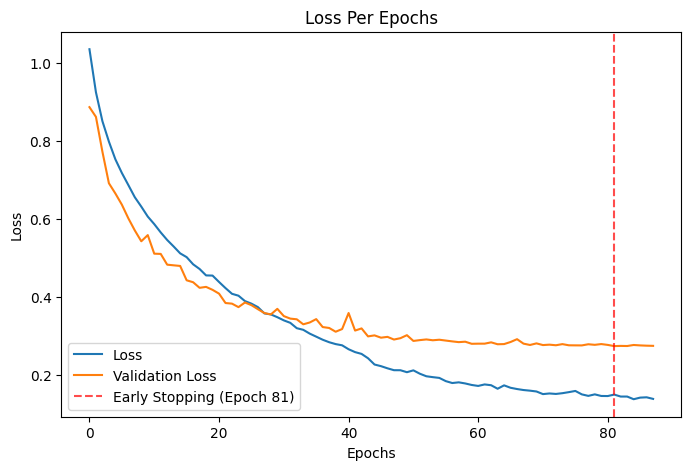

In [ ]:
best_epoch = train_hist_m2["val_loss"].idxmin()

plt.figure(figsize=(8, 5))
plt.plot(train_hist_m2[["loss", "val_loss"]])

plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7)

plt.legend(["Loss", "Validation Loss", f"Early Stopping (Epoch {best_epoch})"])
plt.title("Loss Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

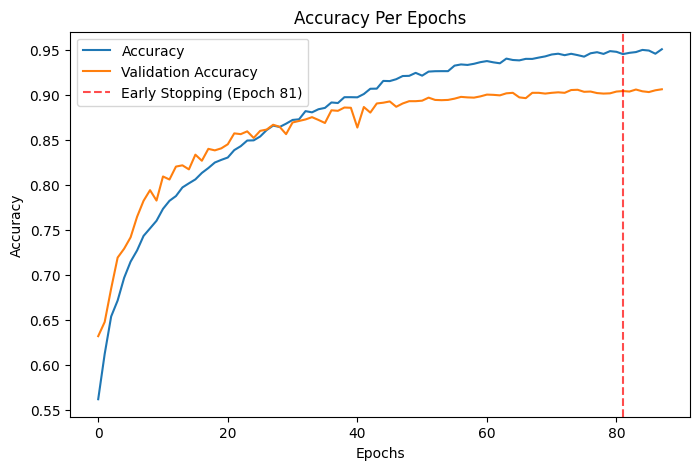

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m2[["accuracy", "val_accuracy"]])

plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7)

plt.legend(["Accuracy", "Validation Accuracy", f"Early Stopping (Epoch {best_epoch})"])
plt.title("Accuracy Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
Log_Model(CNN1D_Model, "CNN1D", xvalid, yvalid, train_m2)
log

,model,accuracy,train_time,pred_time
0,ANN,90.227848,120.56,0.368
1,CNN1D,90.436006,5698.52,2.723


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


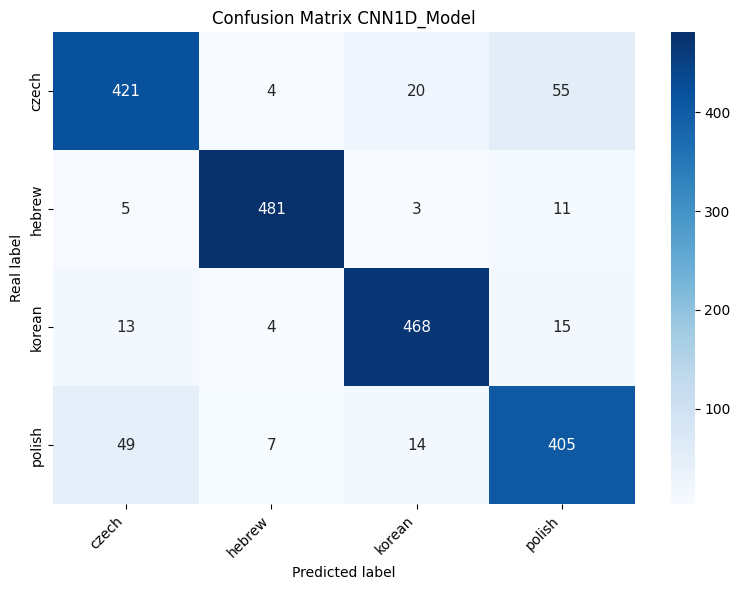

In [ ]:
model, test_x_raw, test_y = CNN1D_Model, xTest, yTest

test_x = np.expand_dims(test_x_raw, axis=2)

y_pred = model.predict(test_x)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_y, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

class_names = le.classes_

plt.figure(figsize=(8, 6), dpi=100)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11})

plt.title('Confusion Matrix CNN1D_Model')
plt.ylabel('Real label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
def CNN1D_Prediction(file_name):
    # load the audio file
    audio_data, sample_rate = librosa.load(file_name, res_type="soxr_hq")
    # get the feature
    feature = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=128)
    # scale the features
    feature_scaled = np.mean(feature.T, axis=0)
    # array of features
    prediction_feature = np.array([feature_scaled])
    # expand dims
    final_prediction_feature = np.expand_dims(prediction_feature, axis=2)
    # get the id of label using argmax
    predicted_vector = np.argmax(CNN1D_Model.predict(final_prediction_feature), axis=-1)
    # get the class label from class id
    predicted_class = le.inverse_transform(predicted_vector)
    # display the result
    print("CNN1D has predicted the class as  --> ", predicted_class[0])

random_index = np.random.randint(0, len(extracted_df))
file_name = extracted_df.loc[random_index, 'path']
print(f"Randomly selected file for CNN1D_Prediction: {file_name}")

# get the output
CNN1D_Prediction(file_name)
# play the file
ipd.Audio(file_name)

Randomly selected file for CNN1D_Prediction: /content/drive/MyDrive/voices/czech/clips/common_voice_cs_36648441.mp3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
CNN1D has predicted the class as  -->  czech


# CNN2D_Model

## 1. Architektura modelu

Model zbudowany jest jako 2D Convolutional Neural Network z wykorzystaniem interfejsu `Sequential` biblioteki Keras/TensorFlow. W odróżnieniu od CNN1D, która przetwarza sekwencję cech jako sygnał jednowymiarowy, CNN2D traktuje macierz MFCC jako obraz dwuwymiarowy o kształcie `(16, 8, 1)` – gdzie oś pionowa odpowiada współczynnikom MFCC, oś pozioma ramkom czasowym, a kanał jest pojedynczy (skala szarości). Pozwala to na jednoczesne wyodrębnianie wzorców zarówno w wymiarze spektralnym, jak i temporalnym.

### Schemat warstw

| Blok | Warstwa | Filtry / Neurony | Kernel / Pool | Aktywacja | Regularyzacja |
|---|---|---|---|---|---|
| Blok 1 | Conv2D | 64 | (3×3), padding=same | ReLU | BatchNorm + MaxPool(2×2) + Dropout(0.25) |
| Blok 2 | Conv2D | 128 | (3×3), padding=same | ReLU | BatchNorm + MaxPool(2×2) + Dropout(0.25) |
| Klasyfikator | Flatten → Dense | 512 | – | ReLU | Dropout(0.5) |
| Wyjście | Dense | `num_labels` | – | Softmax | – |

### Opis poszczególnych elementów

**Dane wejściowe – macierz MFCC jako obraz 2D**  
Wejście modelu ma kształt `(16, 8, 1)`: 16 współczynników MFCC (oś częstotliwościowa) × 8 ramek czasowych × 1 kanał. Taka reprezentacja umożliwia filtrowi splotowemu 2D wykrywanie lokalnych struktur jednocześnie w obu wymiarach – np. charakterystycznych przejść czasowych przy określonych pasmach częstotliwości, co jest trudne do uchwycenia w modelu ANN lub CNN1D.

**Warstwy splotowe Conv2D**  
Filtry o rozmiarze jądra `(3×3)` przesuwane są po macierzy wejściowej w obu wymiarach. Padding `"same"` zachowuje wymiary przestrzenne tensora po splotaniu, dzięki czemu MaxPooling redukuje je w kontrolowany sposób. Liczba filtrów rośnie: 64 (blok 1) → 128 (blok 2), co odzwierciedla hierarchię od prostych detektorów krawędzi spektralnych do bardziej złożonych wzorców językowo-akustycznych. W CNN2D aktywacja ReLU zdefiniowana jest bezpośrednio w warstwie Conv2D (argument `activation="relu"`), a nie jako osobna warstwa.

**Batch Normalization**  
Normalizuje aktywacje po każdym bloku splotowym, stabilizując trening i ograniczając wrażliwość na inicjalizację wag.

**MaxPool2D (pool_size=(2, 2))**  
Podpróbkowanie dwuwymiarowe – wybiera wartość maksymalną w oknie `2×2` przesuwnym z krokiem domyślnym równym rozmiarowi okna. Redukuje wymiary przestrzenne mapy cech o połowę w obu wymiarach po każdym bloku, zmniejszając liczbę parametrów i wprowadzając niezmienniczość na małe przesunięcia wzorców w obrazie MFCC.

**Dropout (p = 0.25 / 0.5)**  
Regularyzacja przez losowe zerowanie neuronów: 25% po każdym bloku splotowym (niski dropout dla warstw wyodrębniających cechy) oraz 50% po warstwie gęstej (silniejsza regularyzacja w części klasyfikacyjnej, gdzie ryzyko przeuczenia jest największe).

**Flatten**  
Spłaszcza czterowymiarowy tensor `(batch, height, width, filters)` do wektora cech przekazywanego do klasyfikatora.

**Warstwa gęsta (Dense 512)**  
Szeroka warstwa w pełni połączona integruje dwuwymiarowe cechy lokalne wyodrębnione przez bloki splotowe w kompaktową reprezentację globalną wypowiedzi. Większa liczba neuronów (512) niż w CNN1D (256) kompensuje fakt, że CNN2D operuje na znacznie mniejszej macierzy wejściowej `(16×8)`.

**Warstwa wyjściowa – Softmax**  
Przekształca logity na rozkład prawdopodobieństwa po wszystkich `num_labels` klasach językowych.

---

## 2. Kompilacja modelu

```python
CNN2D_Model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
```

Model skompilowany z optymalizatorem **Adam** przy domyślnym współczynniku uczenia `learning_rate=0.001` – wyższy punkt startowy niż w modelach ANN i CNN1D (`0.0005`), co jest wynika z mniejszej złożoności architektury i mniejszym wymiarze wejścia. Funkcja straty `categorical_crossentropy` właściwa dla klasyfikacji wieloklasowej z kodowaniem one-hot.

---

## 3. Trenowanie modelu

### Callbacki

#### Early Stopping
```python
EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
```
Przerywa trening, jeśli `val_loss` nie spada przez **10 kolejnych epok** – identycznie jak w modelu ANN, co jest uzasadnione mniejszą głębokością sieci (2 bloki splotowe vs 4 w CNN1D) i mniejszym ryzykiem szybkiego przeuczenia. Parametr `restore_best_weights=True` przywraca wagi z najlepszej epoki.

#### Model Checkpoint
```python
ModelCheckpoint(filepath="CNN2D_Model_best.keras", monitor='val_accuracy',
                save_best_only=True, mode='max')
```
Zapisuje model na dysk wyłącznie przy osiągnięciu nowego maksimum `val_accuracy`.

#### Reduce LR on Plateau
```python
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001)
```
Zmniejsza współczynnik uczenia o połowę przy braku poprawy `val_loss` przez **4 epoki**, z minimalnym limitem `1e-5`. Tożsame ustawienia jak w CNN1D.

### Dane treningowe i walidacyjne

```python
CNN2D_Results = CNN2D_Model.fit(
    xtrain, yTrain,
    epochs=num_epochs,
    batch_size=128,
    validation_data=(xtest, yTest),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)
```

Dane wejściowe `xtrain` mają kształt `(n_samples, 16, 8, 1)` – macierz MFCC każdego nagrania zreshapowana do formatu obrazu 2D. Etykiety `yTrain` zakodowane są w formacie one-hot. Ewaluacja po każdej epoce odbywa się na zbiorze `xtest` / `yTest`.

---

## 4. Podsumowanie

Model CNN2D interpretuje macierz cech MFCC jako dwuwymiarowy obraz, co pozwala na jednoczesne wykrywanie lokalnych wzorców w wymiarze spektralnym i czasowym za pomocą filtrów `(3×3)`. Architektura jest celowo zwarta – dwa bloki splotowe z rosnącą liczbą filtrów (64→128) i agresywnym poolingiem `(2×2)` – co jest uzasadnione małym wymiarem wejścia `(16×8)`. Silny Dropout (50%) przy warstwie gęstej stanowi kluczowy element regularyzacji. W porównaniu z CNN1D model CNN2D uchwytuje struktury dwuwymiarowe w macierzy MFCC, natomiast CNN1D lepiej modeluje długoterminowe zależności sekwencyjne wzdłuż osi czasu.

In [ ]:
xtrain = xTrain.reshape(xTrain.shape[0], 16, 8, 1)
xtest = xTest.reshape(xTest.shape[0], 16, 8, 1)

print("The Shape of X Train", xtrain.shape)
print("The Shape of Y Train", yTrain.shape)
print("The Shape of X Test", xtest.shape)
print("The Shape of Y Test", yTest.shape)

The Shape of X Train (14220, 16, 8, 1)
The Shape of Y Train (14220, 4)
The Shape of X Test (1975, 16, 8, 1)
The Shape of Y Test (1975, 4)


In [ ]:
CNN2D_Model = Sequential()
CNN2D_Model.add(Conv2D(64, (3, 3), padding="same", activation="relu", input_shape=(16, 8, 1)))
CNN2D_Model.add(BatchNormalization())
CNN2D_Model.add(MaxPool2D(pool_size=(2, 2)))
CNN2D_Model.add(Dropout(0.25))

CNN2D_Model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
CNN2D_Model.add(BatchNormalization())
CNN2D_Model.add(MaxPool2D(pool_size=(2, 2)))
CNN2D_Model.add(Dropout(0.25))

CNN2D_Model.add(Flatten())
CNN2D_Model.add(Dense(512, activation="relu"))
CNN2D_Model.add(Dropout(0.5))
CNN2D_Model.add(Dense(num_labels, activation="softmax"))
CNN2D_Model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
CNN2D_Model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 8, 64)      │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 8, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602,116 (2.30 MB)

 Trainable params: 601,732 (2.30 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
import time
import pandas as pd

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    filepath="CNN2D_Model_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001)

t0 = time.time()

CNN2D_Results = CNN2D_Model.fit(
    xtrain, yTrain,
    epochs=num_epochs,
    batch_size=128,
    validation_data=(xtest, yTest),
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

CNN2D_Model.save("CNN2D_Model_Final.keras")
print("CNN2D Model Saved Successfully")

train_hist_m3 = pd.DataFrame(CNN2D_Results.history)
train_m3 = round(time.time() - t0, 3)
print(f"Czas trenowania: {train_m3} sekund")

Epoch 1/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.9202 - loss: 0.2107 - val_accuracy: 0.8982 - val_loss: 0.3184 - learning_rate: 1.2500e-04
Epoch 2/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - accuracy: 0.9220 - loss: 0.2107 - val_accuracy: 0.8922 - val_loss: 0.3166 - learning_rate: 1.2500e-04
Epoch 3/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.9285 - loss: 0.1980 - val_accuracy: 0.8922 - val_loss: 0.3166 - learning_rate: 1.2500e-04
Epoch 4/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.9285 - loss: 0.1963 - val_accuracy: 0.8982 - val_loss: 0.3253 - learning_rate: 1.2500e-04
Epoch 5/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.9264 - loss: 0.1977 - val_accuracy: 0.8952 - val_loss: 0.3163 - learning_rate: 1.2500e-04
Epoch 6/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.9267 - loss: 0.1932 - val_accuracy: 0.8937 - val_loss: 0.3131 - learning_rate: 1.2500e-04
Epoch 7/150
112/112 ━━━━━━━━━━━━━━━━━━━━

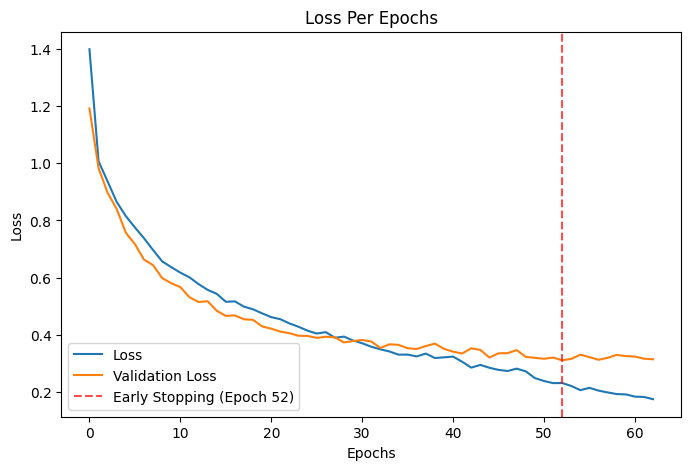

In [ ]:
best_epoch = train_hist_m3["val_loss"].idxmin()

plt.figure(figsize=(8, 5), dpi=100)
plt.plot(train_hist_m3[["loss", "val_loss"]])

plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7)

plt.legend(["Loss", "Validation Loss", f"Early Stopping (Epoch {best_epoch})"])
plt.title("Loss Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

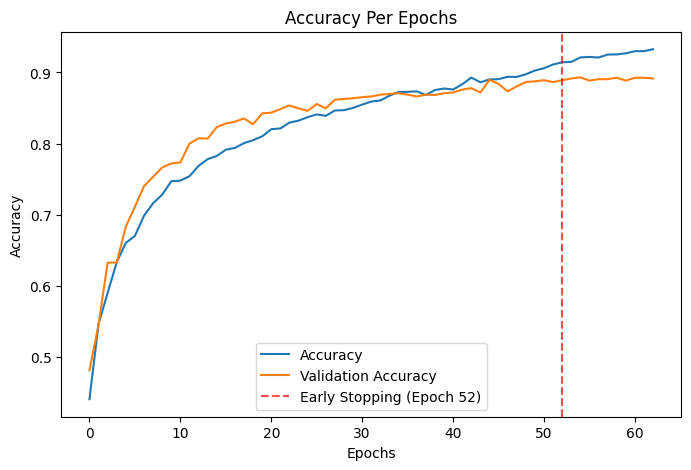

In [ ]:
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(train_hist_m3[["accuracy", "val_accuracy"]])

plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7)

plt.legend(["Accuracy", "Validation Accuracy", f"Early Stopping (Epoch {best_epoch})"])
plt.title("Accuracy Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
Log_Model(CNN2D_Model, "CNN2D", xtest, yTest, train_m3)
log

,model,accuracy,train_time,pred_time
0,ANN,90.227848,120.560,0.368
1,CNN1D,90.436006,5698.520,2.723
2,CNN2D,88.911390,1052.975,0.724


In [ ]:
# function to predict the feature
def CNN2D_Prediction(file_name):
    # load the audio file
    audio_data, sample_rate = librosa.load(file_name, res_type="soxr_hq")
    # get the feature
    feature = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=128)
    # scale the features
    feature_scaled = np.mean(feature.T, axis=0)
    # array of features
    prediction_feature = np.array([feature_scaled])
    # reshaping the features
    final_prediction_feature = prediction_feature.reshape(
        prediction_feature.shape[0], 16, 8, 1
    )
    # get the id of label using argmax
    predicted_vector = np.argmax(CNN2D_Model.predict(final_prediction_feature), axis=-1)
    # get the class label from class id
    predicted_class = le.inverse_transform(predicted_vector)
    # display the result
    print("CNN2D has predicted the class as  --> ", predicted_class[0])


random_index = np.random.randint(0, len(extracted_df))
file_name = extracted_df.loc[random_index, 'path']
print(f"Randomly selected file for CNN2D_Prediction: {file_name}")
# get the output
CNN2D_Prediction(file_name)
# play the file
ipd.Audio(file_name)

Randomly selected file for CNN2D_Prediction: /content/drive/MyDrive/voices/polish/clips/common_voice_pl_23901898.mp3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
CNN2D has predicted the class as  -->  polish


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


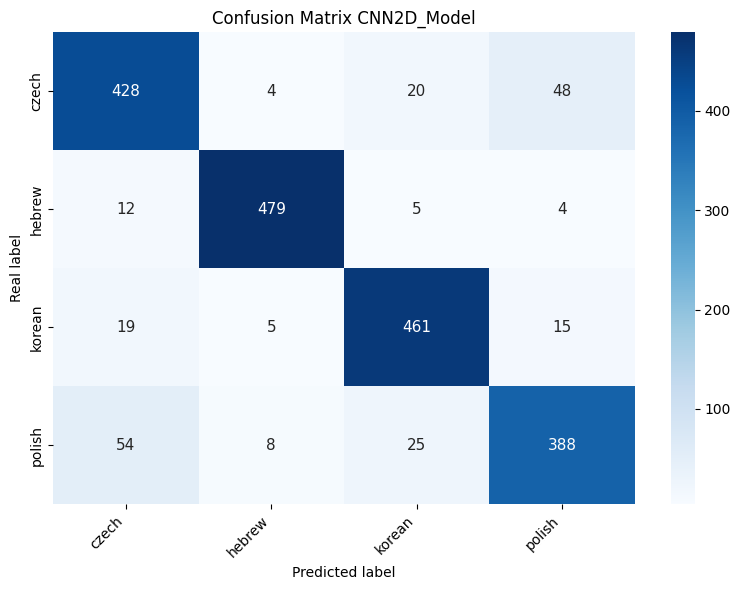

In [ ]:
model, test_x, test_y = CNN2D_Model, xtest, yTest

y_pred = model.predict(test_x)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_y, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

class_names = le.classes_

plt.figure(figsize=(8, 6), dpi=100)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11})

plt.title('Confusion Matrix CNN2D_Model')
plt.ylabel('Real label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

WYNIKI

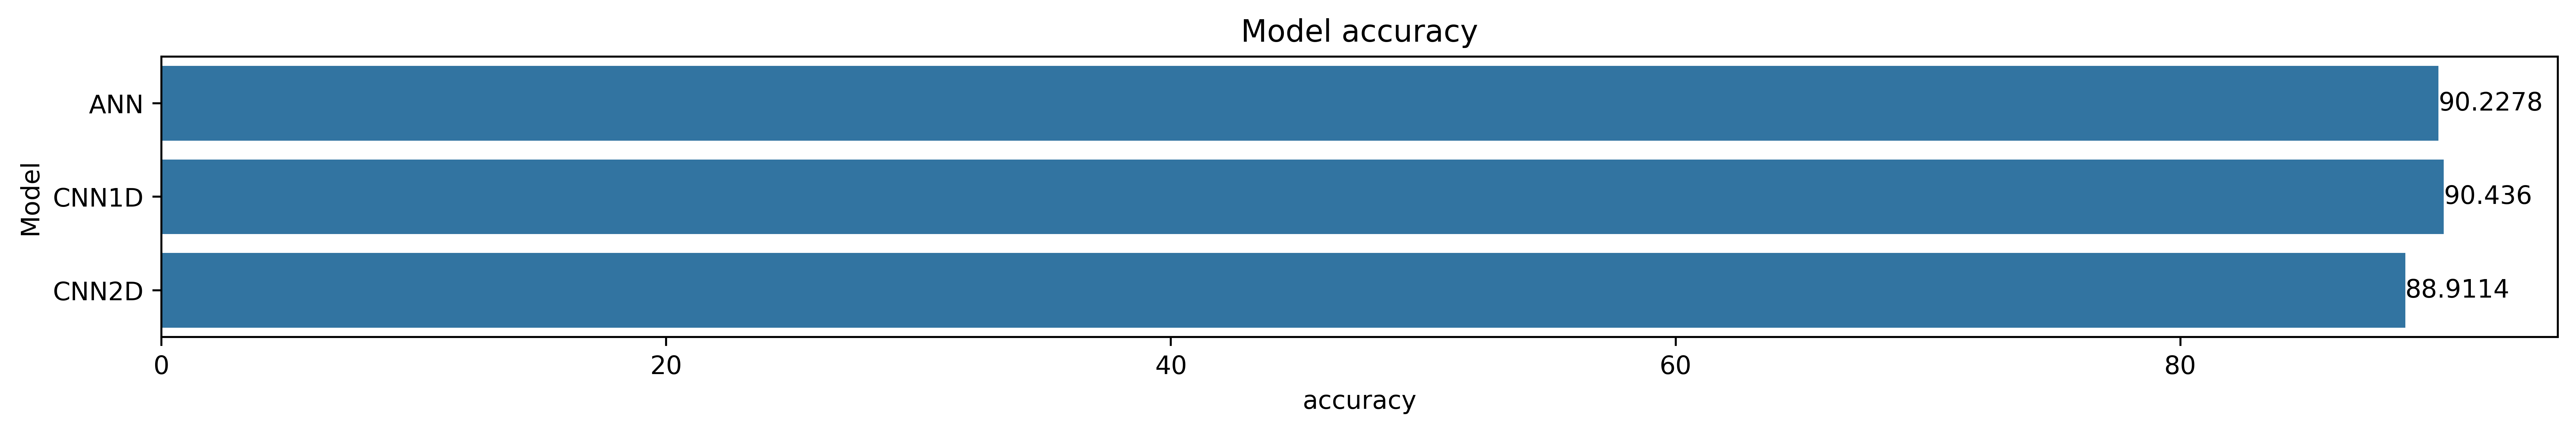

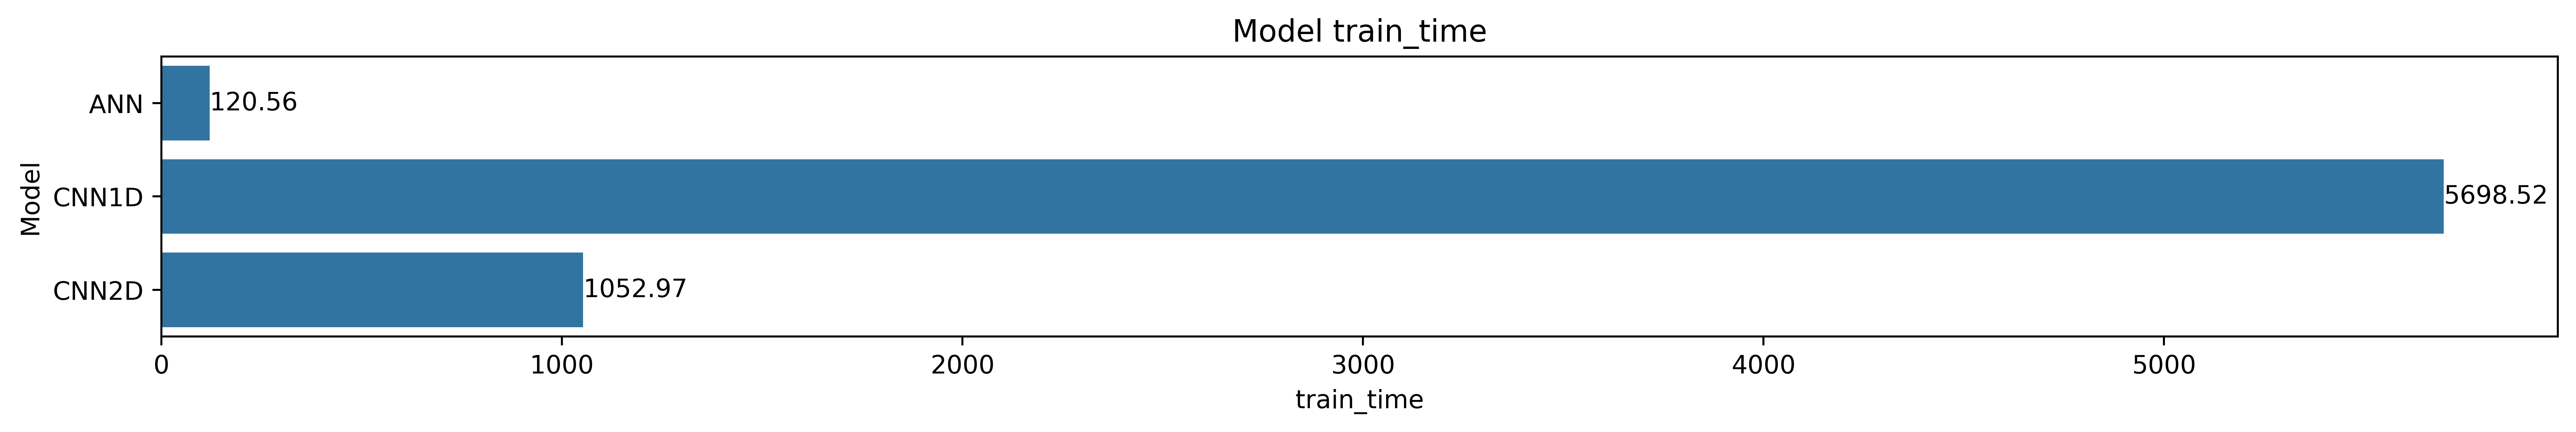

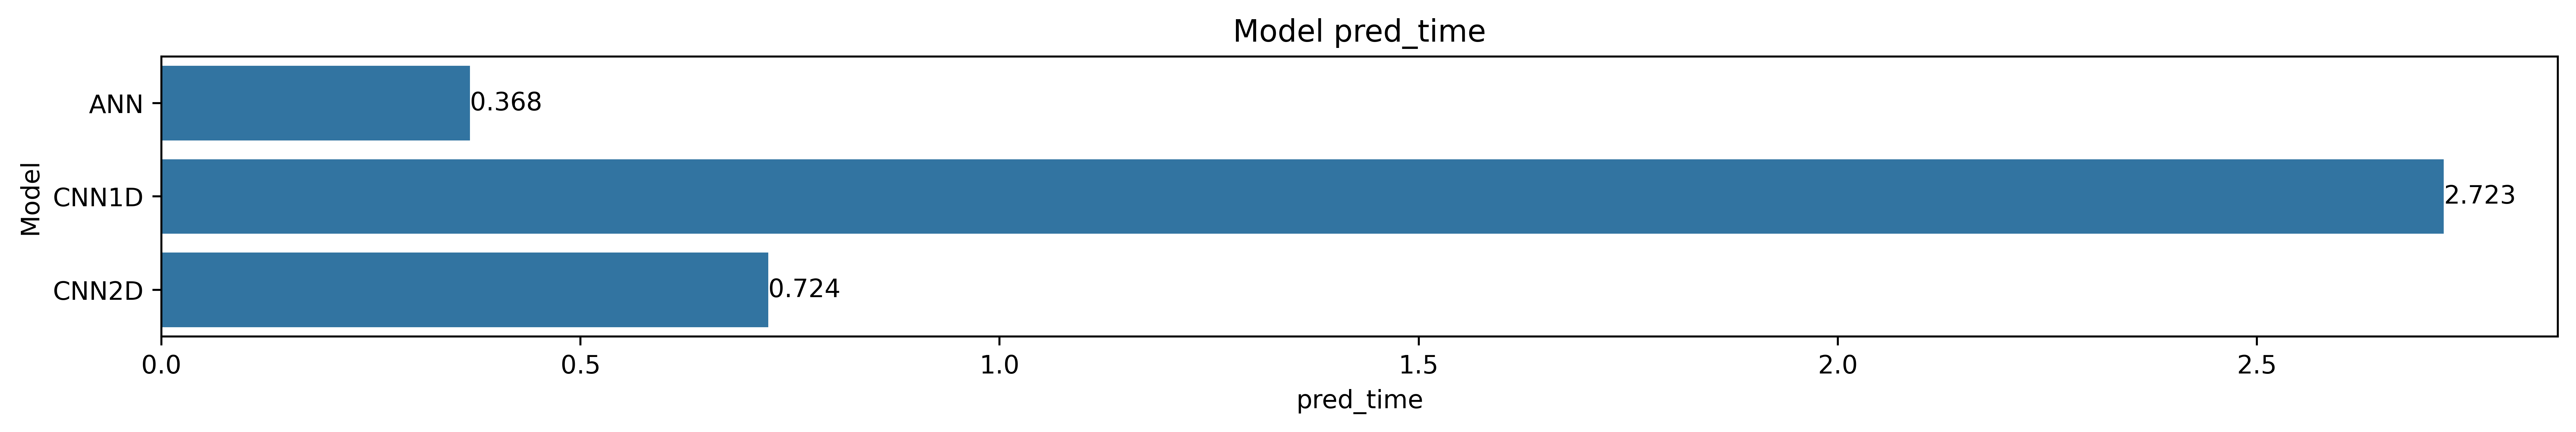

In [ ]:
plt.rcParams["figure.figsize"] = (17, 2)
plt.rcParams["figure.dpi"] = 550

def plot_log(what):
    ax = sns.barplot(x=what, y="model", data=log)
    ax.bar_label(ax.containers[0])
    plt.xlabel(what)
    plt.ylabel("Model")
    plt.title(f"Model {what}")
    return plt.show()

plot_log("accuracy")
plot_log("train_time (s)")
plot_log("pred_time (s)")

WNIOSKI